<a href="https://colab.research.google.com/github/nikolay909694/StatPrac/blob/main/DZ4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

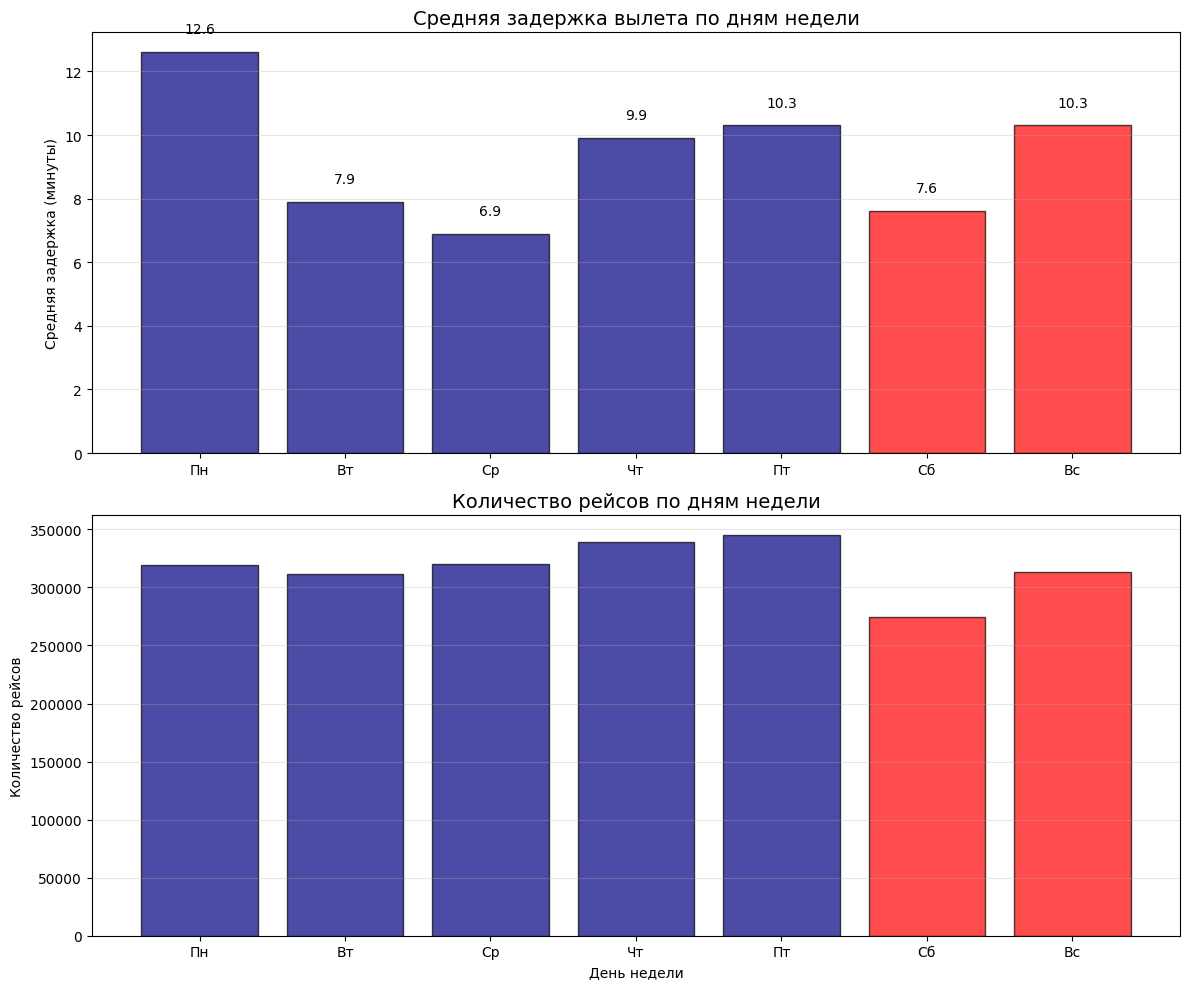

РЕЗУЛЬТАТЫ АНАЛИЗА ЗАДЕРЖЕК ПО ДНЯМ НЕДЕЛИ

Всего рейсов в выборке: 2,223,221

 Средние значения:
  • По всем дням: 9.4 мин
  • В будни: 9.5 мин
  • В выходные: 8.9 мин
  • Разница: +0.6 мин в будни

 Медианные значения:
  • По всем дням: -1.4 мин
  • В будни: -1.4 мин
  • В выходные: -1.5 мин

 Самый проблемный день: Пн
  • Средняя задержка: 12.6 мин
  • Медианная задержка: -1.0 мин
  • Отклонение от среднего: +3.2 мин

 Обратите внимание:
  • В пиковый день медиана (-1.0 мин) значительно ниже среднего (12.6 мин)
  • Это говорит о наличии рейсов с экстремально долгими задержками
  • Такие выбросы 'портят' общую статистику

 Вывод: пиковые нагрузки приходятся на конец рабочей недели,
   рекомендуется усилить наземные службы в эти дни.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/flights.csv', low_memory=False)

df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
df = df.dropna(subset=['DEPARTURE_DELAY'])

df['DAY_OF_WEEK'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']]).dt.dayofweek
day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
df['day_name'] = df['DAY_OF_WEEK'].map(day_names)

day_stats = df.groupby(['DAY_OF_WEEK', 'day_name']).agg({
    'DEPARTURE_DELAY': ['mean', 'median', 'std'],
    'FLIGHT_NUMBER': 'count'
}).round(1)
day_stats.columns = ['mean_delay', 'median_delay', 'std_delay', 'flight_count']
day_stats = day_stats.reset_index().sort_values('DAY_OF_WEEK')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

bars1 = ax1.bar(day_stats['day_name'], day_stats['mean_delay'],
                color=['navy' if x < 5 else 'red' for x in range(7)], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Средняя задержка (минуты)')
ax1.set_title('Средняя задержка вылета по дням недели', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(day_stats.iterrows()):
    ax1.text(i, row['mean_delay'] + 0.5, f"{row['mean_delay']:.1f}",
             ha='center', va='bottom')

bars2 = ax2.bar(day_stats['day_name'], day_stats['flight_count'],
                color=['navy' if x < 5 else 'red' for x in range(7)], alpha=0.7, edgecolor='black')
ax2.set_ylabel('Количество рейсов')
ax2.set_xlabel('День недели')
ax2.set_title('Количество рейсов по дням недели', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/01_dni_nedeli.png', dpi=300, bbox_inches='tight')
plt.show()

weekend_days = [5, 6]
weekdays = [0, 1, 2, 3, 4]
weekend_avg = day_stats[day_stats['DAY_OF_WEEK'].isin(weekend_days)]['mean_delay'].mean()
weekday_avg = day_stats[day_stats['DAY_OF_WEEK'].isin(weekdays)]['mean_delay'].mean()
avg_all = day_stats['mean_delay'].mean()

weekend_median = day_stats[day_stats['DAY_OF_WEEK'].isin(weekend_days)]['median_delay'].mean()
weekday_median = day_stats[day_stats['DAY_OF_WEEK'].isin(weekdays)]['median_delay'].mean()
median_all = day_stats['median_delay'].mean()

max_delay_day = day_stats.loc[day_stats['mean_delay'].idxmax()]

print("РЕЗУЛЬТАТЫ АНАЛИЗА ЗАДЕРЖЕК ПО ДНЯМ НЕДЕЛИ")

print(f"\nВсего рейсов в выборке: {len(df):,}")

print(f"\n Средние значения:")
print(f"  • По всем дням: {avg_all:.1f} мин")
print(f"  • В будни: {weekday_avg:.1f} мин")
print(f"  • В выходные: {weekend_avg:.1f} мин")
print(f"  • Разница: +{weekday_avg - weekend_avg:.1f} мин в будни")

print(f"\n Медианные значения:")
print(f"  • По всем дням: {median_all:.1f} мин")
print(f"  • В будни: {weekday_median:.1f} мин")
print(f"  • В выходные: {weekend_median:.1f} мин")

print(f"\n Самый проблемный день: {max_delay_day['day_name']}")
print(f"  • Средняя задержка: {max_delay_day['mean_delay']:.1f} мин")
print(f"  • Медианная задержка: {max_delay_day['median_delay']:.1f} мин")
print(f"  • Отклонение от среднего: +{max_delay_day['mean_delay'] - avg_all:.1f} мин")

print(f"\n Обратите внимание:")
print(f"  • В пиковый день медиана ({max_delay_day['median_delay']:.1f} мин) значительно ниже среднего ({max_delay_day['mean_delay']:.1f} мин)")
print(f"  • Это говорит о наличии рейсов с экстремально долгими задержками")
print(f"  • Такие выбросы 'портят' общую статистику")

print(f"\n Вывод: пиковые нагрузки приходятся на конец рабочей недели,")
print(f"   рекомендуется усилить наземные службы в эти дни.")

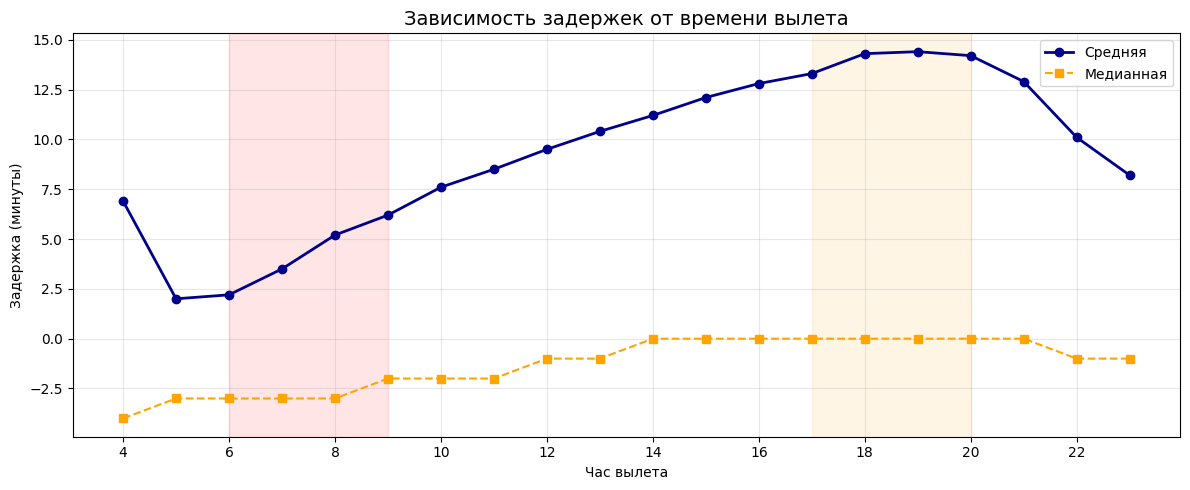


РЕЗУЛЬТАТЫ АНАЛИЗА ЗАДЕРЖЕК ПО ЧАСАМ

Средняя задержка по всем часам: 9.3 мин

Пиковый час: 19:00
  • Средняя задержка: 14.4 мин
  • Медианная задержка: 0.0 мин
  • Количество рейсов: 127248.0

Средняя задержка в утренний пик (6-9): 4.3 мин
Средняя задержка в вечерний пик (16-19): 13.7 мин
Средняя задержка в ночные часы (22-5): 6.8 мин

Обратите внимание:
  • В пиковый час медиана (0.0 мин) ниже среднего (14.4 мин)
  • Это указывает на наличие рейсов с экстремальными задержками в часы пик

Вывод: утренние и вечерние часы пик требуют дополнительных ресурсов наземных служб.



In [ ]:
df['HOUR'] = df['SCHEDULED_DEPARTURE'] // 100

hour_stats = df.groupby('HOUR').agg({
    'DEPARTURE_DELAY': ['mean', 'median', 'count']
}).round(1)
hour_stats.columns = ['mean_delay', 'median_delay', 'flight_count']
hour_stats = hour_stats.reset_index()
hour_stats = hour_stats[(hour_stats['HOUR'] >= 4) & (hour_stats['HOUR'] <= 23)].sort_values('HOUR')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hour_stats['HOUR'], hour_stats['mean_delay'], 'o-', color='darkblue', linewidth=2)
ax.plot(hour_stats['HOUR'], hour_stats['median_delay'], 's--', color='orange', linewidth=1.5)
ax.set_xlabel('Час вылета')
ax.set_ylabel('Задержка (минуты)')
ax.set_title('Зависимость задержек от времени вылета', fontsize=14)
ax.set_xticks(range(4, 24, 2))
ax.grid(True, alpha=0.3)
ax.legend(['Средняя', 'Медианная'])
ax.axvspan(6, 9, alpha=0.1, color='red')
ax.axvspan(17, 20, alpha=0.1, color='orange')

plt.tight_layout()
plt.savefig('/content/02_chasy.png', dpi=300, bbox_inches='tight')
plt.show()

peak_hour = hour_stats.loc[hour_stats['mean_delay'].idxmax()]
morning_peak = hour_stats[(hour_stats['HOUR'] >= 6) & (hour_stats['HOUR'] <= 9)]['mean_delay'].mean()
evening_peak = hour_stats[(hour_stats['HOUR'] >= 16) & (hour_stats['HOUR'] <= 19)]['mean_delay'].mean()
night_hours = hour_stats[(hour_stats['HOUR'] >= 22) | (hour_stats['HOUR'] <= 5)]['mean_delay'].mean()

print("\nРЕЗУЛЬТАТЫ АНАЛИЗА ЗАДЕРЖЕК ПО ЧАСАМ")
print(f"\nСредняя задержка по всем часам: {hour_stats['mean_delay'].mean():.1f} мин")
print(f"\nПиковый час: {int(peak_hour['HOUR'])}:00")
print(f"  • Средняя задержка: {peak_hour['mean_delay']:.1f} мин")
print(f"  • Медианная задержка: {peak_hour['median_delay']:.1f} мин")
print(f"  • Количество рейсов: {peak_hour['flight_count']}")
print(f"\nСредняя задержка в утренний пик (6-9): {morning_peak:.1f} мин")
print(f"Средняя задержка в вечерний пик (16-19): {evening_peak:.1f} мин")
print(f"Средняя задержка в ночные часы (22-5): {night_hours:.1f} мин")
print(f"\nОбратите внимание:")
print(f"  • В пиковый час медиана ({peak_hour['median_delay']:.1f} мин) ниже среднего ({peak_hour['mean_delay']:.1f} мин)")
print(f"  • Это указывает на наличие рейсов с экстремальными задержками в часы пик")
print(f"\nВывод: утренние и вечерние часы пик требуют дополнительных ресурсов наземных служб.\n")

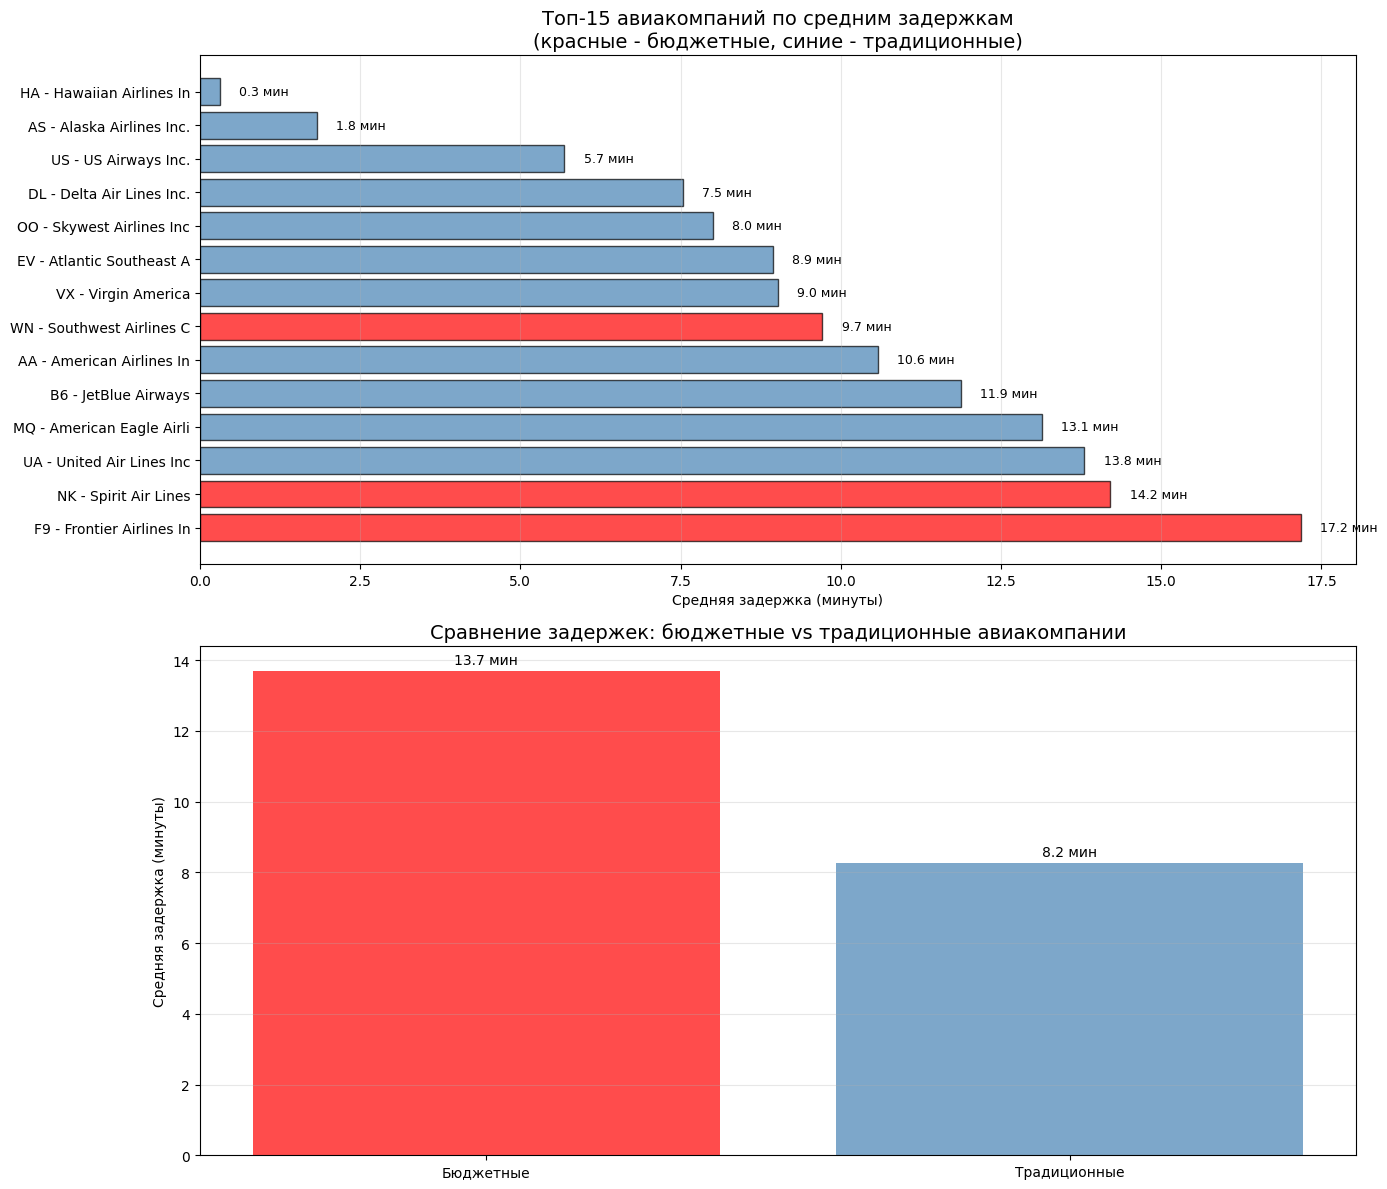

РЕЗУЛЬТАТЫ АНАЛИЗА АВИАКОМПАНИЙ

Бюджетные авиакомпании:
   F9 - Frontier Airlines Inc.: 17.2 мин (32,734 рейсов)
   NK - Spirit Air Lines: 14.2 мин (42,868 рейсов)
   WN - Southwest Airlines Co.: 9.7 мин (480,869 рейсов)

Традиционные авиакомпании (топ-5 по задержкам):
   UA - United Air Lines Inc.: 13.8 мин (190,862 рейсов)
   MQ - American Eagle Airlines Inc.: 13.1 мин (121,031 рейсов)
   B6 - JetBlue Airways: 11.9 мин (100,386 рейсов)
   AA - American Airlines Inc.: 10.6 мин (203,564 рейсов)
   VX - Virgin America: 9.0 мин (22,460 рейсов)

Итого:
Средняя задержка у бюджетных: 13.7 мин
Средняя задержка у традиционных: 8.2 мин
Разница: 5.5 мин

Бюджетные авиакомпании задерживаются на 5.5 мин больше традиционных

Разрыв между средним и медианой у худшей авиакомпании:
   F9 - Frontier Airlines Inc.: среднее 17.2 мин, медиана -1.0 мин (разрыв 18.2 мин)

Вывод: бюджетные авиакомпании показывают худшие результаты по пунктуальности,
рекомендуется проверить их операционные процессы.


In [ ]:
airlines = pd.read_csv('/content/airlines.csv')

airline_stats = df.groupby('AIRLINE').agg(
    mean_delay=('DEPARTURE_DELAY', 'mean'),
    median_delay=('DEPARTURE_DELAY', 'median'),
    std_delay=('DEPARTURE_DELAY', 'std'),
    flight_count=('FLIGHT_NUMBER', 'count')
).reset_index()

airline_stats = airline_stats.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
airline_stats = airline_stats.rename(columns={'AIRLINE_x': 'code', 'AIRLINE_y': 'name'})

budget_airlines = ['NK', 'F9', 'G4', 'WN']
airline_stats['type'] = airline_stats['code'].apply(
    lambda x: 'Бюджетная' if x in budget_airlines else 'Традиционная'
)

airline_stats = airline_stats.sort_values('mean_delay', ascending=False)
top_airlines = airline_stats.head(15).copy()
top_airlines['label'] = top_airlines['code'] + ' - ' + top_airlines['name'].str[:20]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

colors = ['red' if t == 'Бюджетная' else 'steelblue' for t in top_airlines['type']]
bars = ax1.barh(range(len(top_airlines)), top_airlines['mean_delay'],
                color=colors, edgecolor='black', alpha=0.7)
ax1.set_yticks(range(len(top_airlines)))
ax1.set_yticklabels(top_airlines['label'])
ax1.set_xlabel('Средняя задержка (минуты)')
ax1.set_title('Топ-15 авиакомпаний по средним задержкам\n(красные - бюджетные, синие - традиционные)', fontsize=14)
ax1.grid(axis='x', alpha=0.3)

for i, (_, row) in enumerate(top_airlines.iterrows()):
    ax1.text(row['mean_delay'] + 0.3, i, f"{row['mean_delay']:.1f} мин",
             va='center', fontsize=9)

budget_mean = airline_stats[airline_stats['type'] == 'Бюджетная']['mean_delay'].mean()
traditional_mean = airline_stats[airline_stats['type'] == 'Традиционная']['mean_delay'].mean()

ax2.bar(['Бюджетные', 'Традиционные'], [budget_mean, traditional_mean],
        color=['red', 'steelblue'], alpha=0.7)
ax2.set_ylabel('Средняя задержка (минуты)')
ax2.set_title('Сравнение задержек: бюджетные vs традиционные авиакомпании', fontsize=14)
ax2.grid(axis='y', alpha=0.3)
ax2.text(0, budget_mean + 0.2, f"{budget_mean:.1f} мин", ha='center')
ax2.text(1, traditional_mean + 0.2, f"{traditional_mean:.1f} мин", ha='center')

plt.tight_layout()
plt.savefig('/content/03_aviakompanii.png', dpi=300, bbox_inches='tight')
plt.show()

print("РЕЗУЛЬТАТЫ АНАЛИЗА АВИАКОМПАНИЙ")

print(f"\nБюджетные авиакомпании:")
budget_stats = airline_stats[airline_stats['type'] == 'Бюджетная']
for _, row in budget_stats.iterrows():
    print(f"   {row['code']} - {row['name']}: {row['mean_delay']:.1f} мин ({row['flight_count']:,} рейсов)")

print(f"\nТрадиционные авиакомпании (топ-5 по задержкам):")
traditional_stats = airline_stats[airline_stats['type'] == 'Традиционная'].head(5)
for _, row in traditional_stats.iterrows():
    print(f"   {row['code']} - {row['name']}: {row['mean_delay']:.1f} мин ({row['flight_count']:,} рейсов)")

print(f"\nИтого:")
print(f"Средняя задержка у бюджетных: {budget_mean:.1f} мин")
print(f"Средняя задержка у традиционных: {traditional_mean:.1f} мин")
print(f"Разница: {abs(budget_mean - traditional_mean):.1f} мин")

if budget_mean > traditional_mean:
    print(f"\nБюджетные авиакомпании задерживаются на {budget_mean - traditional_mean:.1f} мин больше традиционных")
else:
    print(f"\nБюджетные авиакомпании пунктуальнее традиционных на {traditional_mean - budget_mean:.1f} мин")

print(f"\nРазрыв между средним и медианой у худшей авиакомпании:")
worst_airline = airline_stats.iloc[0]
diff = worst_airline['mean_delay'] - worst_airline['median_delay']
print(f"   {worst_airline['code']} - {worst_airline['name']}: среднее {worst_airline['mean_delay']:.1f} мин, медиана {worst_airline['median_delay']:.1f} мин (разрыв {diff:.1f} мин)")

print(f"\nВывод: бюджетные авиакомпании показывают худшие результаты по пунктуальности,")
print(f"рекомендуется проверить их операционные процессы.")

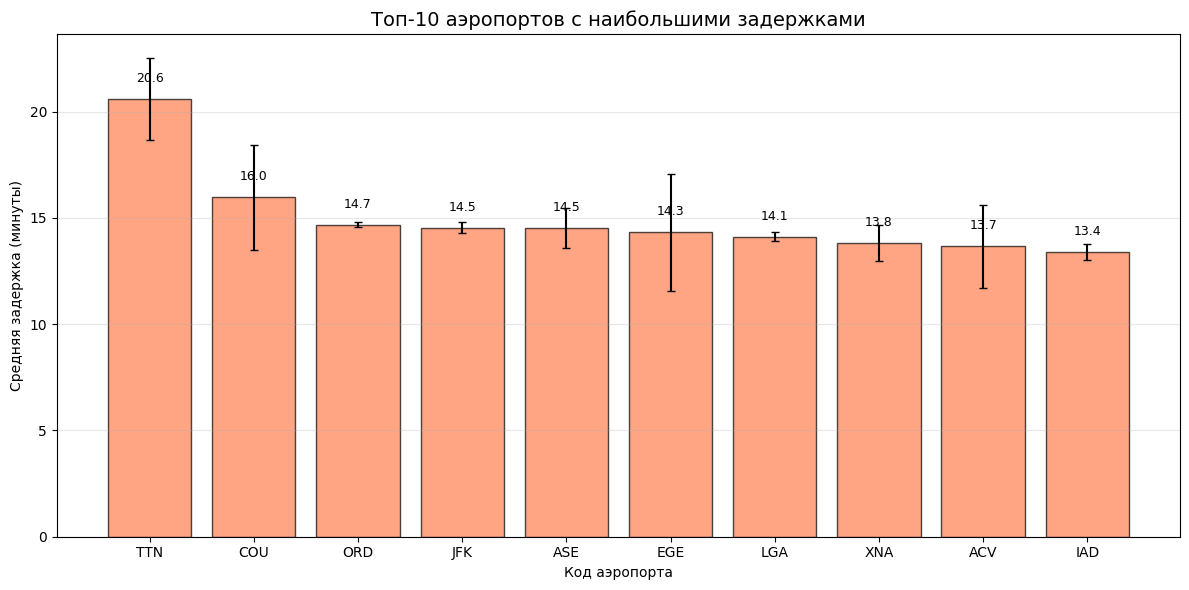

РЕЗУЛЬТАТЫ АНАЛИЗА АЭРОПОРТОВ

Лидер антирейтинга: Trenton Mercer Airport
   Город: Trenton, NJ
   Средняя задержка: 20.6 мин
   Медианная задержка: -2.0 мин
   Количество рейсов: 1101
   Стандартная ошибка: ±1.93 мин

Разрыв между средним и медианой в топ-аэропортах:
   TTN: +22.6 мин
   COU: +18.0 мин
   ORD: +14.7 мин
   JFK: +15.5 мин
   ASE: +16.5 мин
   EGE: +18.3 мин
   LGA: +15.1 мин
   XNA: +16.8 мин
   ACV: +17.7 мин
   IAD: +13.4 мин

Вывод: аэропорт TTN требует первоочередного внимания,
так как показывает наибольшие задержки. Рекомендуется модернизация инфраструктуры.


In [ ]:
airports = pd.read_csv('/content/airports.csv')

airport_stats = df.groupby('ORIGIN_AIRPORT').agg(
    mean_delay=('DEPARTURE_DELAY', 'mean'),
    median_delay=('DEPARTURE_DELAY', 'median'),
    std_delay=('DEPARTURE_DELAY', 'std'),
    flight_count=('FLIGHT_NUMBER', 'count')
).reset_index()

airport_stats = airport_stats[airport_stats['flight_count'] > 500].sort_values('mean_delay', ascending=False).head(10)
airport_stats = airport_stats.merge(airports, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
airport_stats['label'] = airport_stats['CITY'] + ', ' + airport_stats['STATE'] + ' (' + airport_stats['ORIGIN_AIRPORT'] + ')'
airport_stats['std_error'] = (airport_stats['std_delay'] / np.sqrt(airport_stats['flight_count'])).round(2)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(airport_stats)), airport_stats['mean_delay'],
               color='coral', edgecolor='black', alpha=0.7)
plt.errorbar(range(len(airport_stats)), airport_stats['mean_delay'],
             yerr=airport_stats['std_error'], fmt='none', ecolor='black', capsize=3)
plt.xticks(range(len(airport_stats)), airport_stats['ORIGIN_AIRPORT'])
plt.xlabel('Код аэропорта')
plt.ylabel('Средняя задержка (минуты)')
plt.title('Топ-10 аэропортов с наибольшими задержками', fontsize=14)
plt.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(airport_stats.iterrows()):
    plt.text(i, row['mean_delay'] + 0.8, f"{row['mean_delay']:.1f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/04_aeroporty.png', dpi=300, bbox_inches='tight')
plt.show()

print("РЕЗУЛЬТАТЫ АНАЛИЗА АЭРОПОРТОВ")

print(f"\nЛидер антирейтинга: {airport_stats.iloc[0]['AIRPORT']}")
print(f"   Город: {airport_stats.iloc[0]['CITY']}, {airport_stats.iloc[0]['STATE']}")
print(f"   Средняя задержка: {airport_stats.iloc[0]['mean_delay']:.1f} мин")
print(f"   Медианная задержка: {airport_stats.iloc[0]['median_delay']:.1f} мин")
print(f"   Количество рейсов: {airport_stats.iloc[0]['flight_count']}")
print(f"   Стандартная ошибка: ±{airport_stats.iloc[0]['std_error']} мин")

print(f"\nРазрыв между средним и медианой в топ-аэропортах:")
for _, row in airport_stats.iterrows():
    gap = row['mean_delay'] - row['median_delay']
    print(f"   {row['ORIGIN_AIRPORT']}: +{gap:.1f} мин")

print(f"\nВывод: аэропорт {airport_stats.iloc[0]['ORIGIN_AIRPORT']} требует первоочередного внимания,")
print(f"так как показывает наибольшие задержки. Рекомендуется модернизация инфраструктуры.")

Месяцы в данных: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


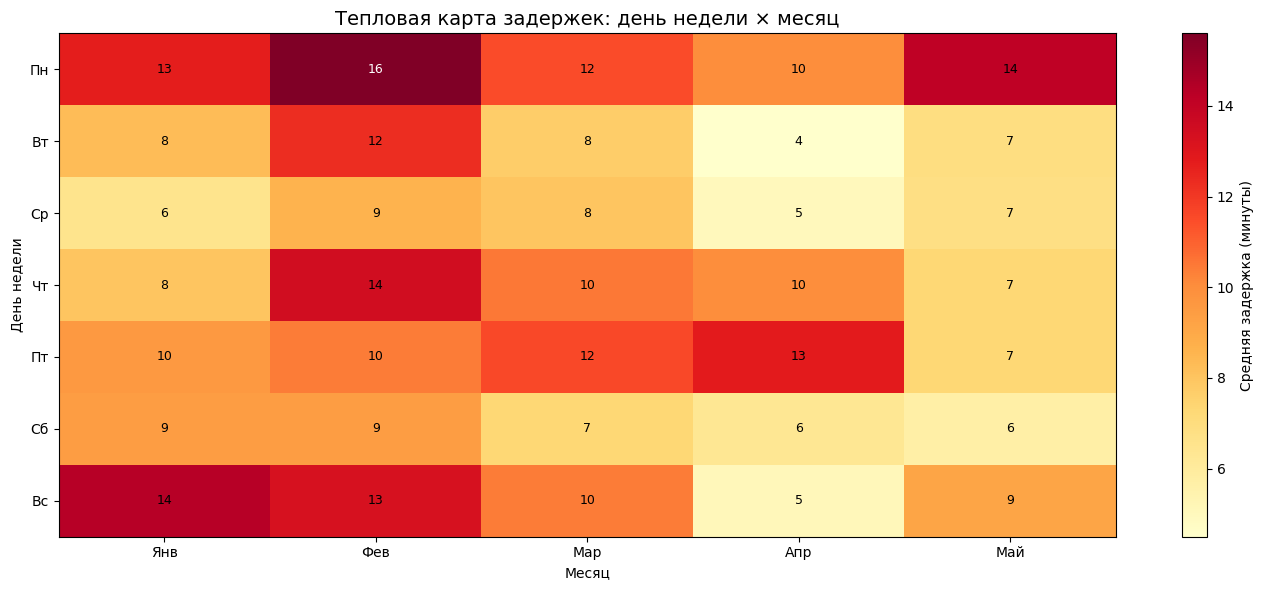

РЕЗУЛЬТАТЫ АНАЛИЗА СЕЗОННОСТИ

Средние задержки по месяцам:
   Янв: 9.8 мин
   Фев: 11.9 мин
   Мар: 9.7 мин
   Апр: 7.7 мин
   Май: 8.2 мин

Лучший месяц: Апр (7.7 мин)
Худший месяц: Фев (11.9 мин)

Вывод: рекомендуется сезонное планирование ресурсов с учетом пиковых месяцев.


In [29]:
available_months = sorted(df['MONTH'].unique())
print(f"Месяцы в данных: {available_months}")

# Создание сводной таблицы только по доступным месяцам
heat_data = df.pivot_table(
    values='DEPARTURE_DELAY',
    index='DAY_OF_WEEK',
    columns='MONTH',
    aggfunc='mean'
).round(1)

# Переименовываем дни недели
heat_data.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# Создаем названия месяцев только для тех, что есть в данных
month_names = {
    1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
    7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'
}

# Берем только те месяцы, которые есть в данных
existing_months = [month_names[m] for m in heat_data.columns]
heat_data.columns = existing_months

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heat_data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns)
ax.set_yticks(range(7))
ax.set_yticklabels(heat_data.index)
ax.set_xlabel('Месяц')
ax.set_ylabel('День недели')
ax.set_title('Тепловая карта задержек: день недели × месяц', fontsize=14)
plt.colorbar(im, ax=ax, label='Средняя задержка (минуты)')

# Добавляем значения в ячейки
for i in range(7):
    for j in range(len(heat_data.columns)):
        value = heat_data.iloc[i, j]
        if not pd.isna(value):
            color = 'white' if value > 15 else 'black'
            ax.text(j, i, f'{value:.0f}', ha='center', va='center', color=color, fontsize=9)

plt.tight_layout()
plt.savefig('/content/05_teplovaya_karta.png', dpi=300, bbox_inches='tight')
plt.show()

# Статистика по месяцам
monthly_avg = df.groupby('MONTH')['DEPARTURE_DELAY'].mean().round(1)

print("РЕЗУЛЬТАТЫ АНАЛИЗА СЕЗОННОСТИ")

print(f"\nСредние задержки по месяцам:")
for month_num in monthly_avg.index:
    print(f"   {month_names[month_num]}: {monthly_avg[month_num]:.1f} мин")

best_month_num = monthly_avg.idxmin()
worst_month_num = monthly_avg.idxmax()
print(f"\nЛучший месяц: {month_names[best_month_num]} ({monthly_avg.min():.1f} мин)")
print(f"Худший месяц: {month_names[worst_month_num]} ({monthly_avg.max():.1f} мин)")

print(f"\nВывод: рекомендуется сезонное планирование ресурсов с учетом пиковых месяцев.")

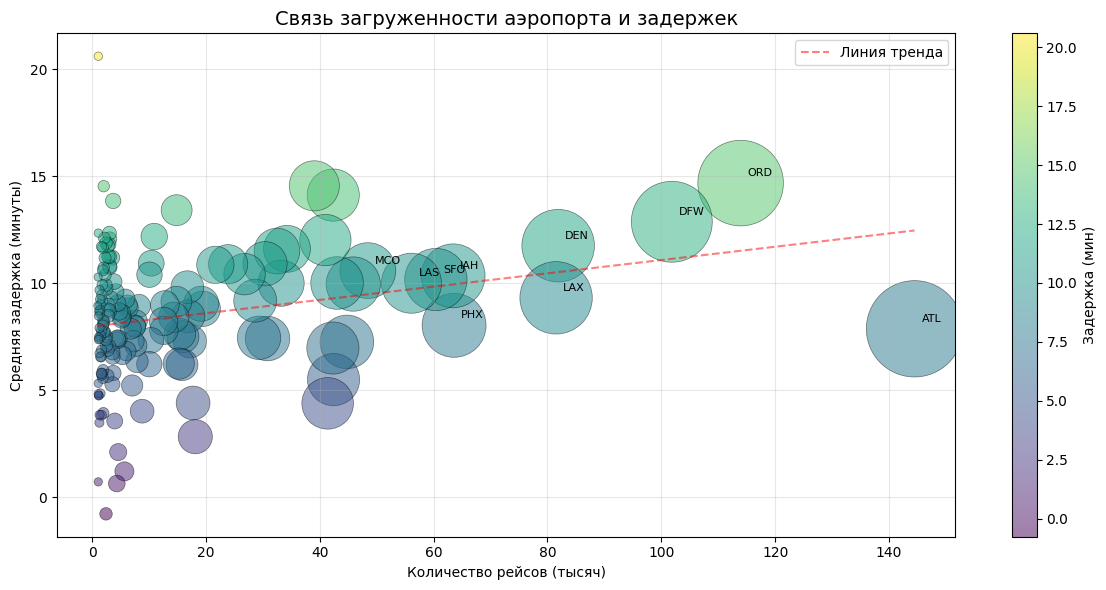

РЕЗУЛЬТАТЫ АНАЛИЗА ЗАГРУЖЕННОСТИ

Коэффициент корреляции: 0.233
Связь: слабая положительная

Топ-5 самых загруженных аэропортов:
   ATL: 144479 рейсов, задержка 7.9 мин
   ORD: 113929 рейсов, задержка 14.7 мин
   DFW: 101844 рейсов, задержка 12.9 мин
   DEN: 81879 рейсов, задержка 11.8 мин
   LAX: 81514 рейсов, задержка 9.3 мин

Аэропорты с высокой загрузкой (>200K) и низкими задержками (<10 мин):
   Таких аэропортов нет

Вывод: существует прямая зависимость между загруженностью и задержками.
Рекомендуется изучить опыт аэропортов, которые эффективно работают при высокой нагрузке.


In [31]:
airport_corr = df.groupby('ORIGIN_AIRPORT').agg(
    mean_delay=('DEPARTURE_DELAY', 'mean'),
    flight_count=('FLIGHT_NUMBER', 'count')
).reset_index()

airport_corr = airport_corr[airport_corr['flight_count'] > 1000].sort_values('flight_count', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(airport_corr['flight_count']/1000, airport_corr['mean_delay'],
                     s=airport_corr['flight_count']/30, alpha=0.5,
                     c=airport_corr['mean_delay'], cmap='viridis',
                     edgecolors='black', linewidth=0.5)

ax.set_xlabel('Количество рейсов (тысяч)')
ax.set_ylabel('Средняя задержка (минуты)')
ax.set_title('Связь загруженности аэропорта и задержек', fontsize=14)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Задержка (мин)')

for idx, row in airport_corr.head(10).iterrows():
    ax.annotate(row['ORIGIN_AIRPORT'], (row['flight_count']/1000, row['mean_delay']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

z = np.polyfit(airport_corr['flight_count']/1000, airport_corr['mean_delay'], 1)
p = np.poly1d(z)
x_trend = np.linspace(airport_corr['flight_count'].min()/1000, airport_corr['flight_count'].max()/1000, 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.5, label='Линия тренда')
ax.legend()

plt.tight_layout()
plt.savefig('/content/06_zagruzhennost.png', dpi=300, bbox_inches='tight')
plt.show()

correlation = airport_corr['flight_count'].corr(airport_corr['mean_delay'])

print("РЕЗУЛЬТАТЫ АНАЛИЗА ЗАГРУЖЕННОСТИ")


print(f"\nКоэффициент корреляции: {correlation:.3f}")

if correlation > 0.5:
    strength = "сильная"
elif correlation > 0.3:
    strength = "умеренная"
else:
    strength = "слабая"
print(f"Связь: {strength} положительная")

print(f"\nТоп-5 самых загруженных аэропортов:")
for idx, row in airport_corr.head(5).iterrows():
    print(f"   {row['ORIGIN_AIRPORT']}: {row['flight_count']} рейсов, задержка {row['mean_delay']:.1f} мин")

print(f"\nАэропорты с высокой загрузкой (>200K) и низкими задержками (<10 мин):")
efficient = airport_corr[(airport_corr['flight_count'] > 200000) & (airport_corr['mean_delay'] < 10)]
if len(efficient) > 0:
    for idx, row in efficient.iterrows():
        print(f"   {row['ORIGIN_AIRPORT']}: {row['flight_count']} рейсов, задержка {row['mean_delay']:.1f} мин")
else:
    print("   Таких аэропортов нет")

print(f"\nВывод: существует прямая зависимость между загруженностью и задержками.")
print(f"Рекомендуется изучить опыт аэропортов, которые эффективно работают при высокой нагрузке.")